### Q1) Implement k-means clustering from scratch on the given dataset and visualize it. 

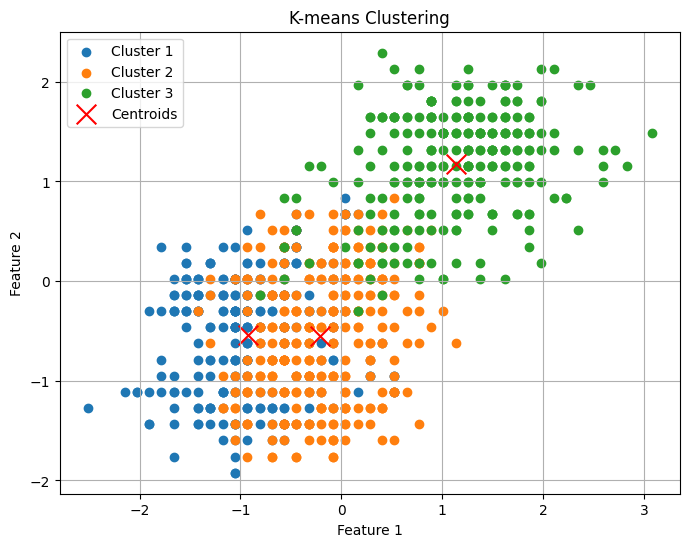

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Function to compute the Euclidean distance between two points
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b)**2))

# K-means clustering algorithm
def k_means(X, k, max_iters=150):
    # Randomly initialize centroids
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]
    
    for _ in range(max_iters):
        # Assign clusters based on nearest centroid
        labels = np.array([
            np.argmin([euclidean_distance(x, centroid) for centroid in centroids])
            for x in X
        ])
        
        # Recalculate centroids
        new_centroids = np.array([
            X[labels == i].mean(axis=0) for i in range(k)
        ])
        
        # Check for convergence
        if np.allclose(centroids, new_centroids):
            break
        
        centroids = new_centroids
    
    return centroids, labels

# Visualize the results
def plot_k_means(X, centroids, labels, k):
    plt.figure(figsize=(8, 6))
    for i in range(k):
        plt.scatter(X[labels == i][:, 0], X[labels == i][:, 1], label=f'Cluster {i+1}')
        
    plt.scatter(centroids[:, 0], centroids[:, 1], color='red', marker='x', s=200, label='Centroids')
    plt.title('K-means Clustering')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.grid(True)
    plt.show()

# Load the dataset
df = pd.read_csv('lab_vehicle.csv')

# Clean column names and drop missing values
df.columns = df.columns.str.strip()
df = df.dropna()

# Manual standardization (mean = 0, std = 1)
scaled_data = (df - df.mean()) / df.std()
scaled_data = scaled_data.values  # Convert to NumPy array

# Set number of clusters
k = 3

# Apply K-means clustering
centroids, labels = k_means(scaled_data, k)

# Visualize the clustering result
plot_k_means(scaled_data, centroids, labels, k)


### Q2) Implement all the discussed cluster evaluation metrics and observe the results for each. 

COMPACTNESS                    0
CIRCULARITY                    0
'DISTANCE CIRCULARITY'         0
'RADIUS RATIO'                 0
'PR.AXIS ASPECT RATIO'         0
'MAX.LENGTH ASPECT RATIO'      0
'SCATTER RATIO'                0
ELONGATEDNESS                  0
'PR.AXIS RECTANGULARITY'       0
'MAX.LENGTH RECTANGULARITY'    0
'SCALED VARIANCE_MAJOR'        0
'SCALED VARIANCE_MINOR'        0
'SCALED RADIUS OF GYRATION'    0
'SKEWNESS ABOUT_MAJOR'         0
'SKEWNESS ABOUT_MINOR'         0
'KURTOSIS ABOUT_MAJOR'         0
'KURTOSIS ABOUT_MINOR'         0
'HOLLOWS RATIO'                0
dtype: int64
Calinski-Harabasz Index: 456.7532373153105
Davies-Bouldin Index: 1.308546386766463
Silhouette Score: 0.29169870902321055


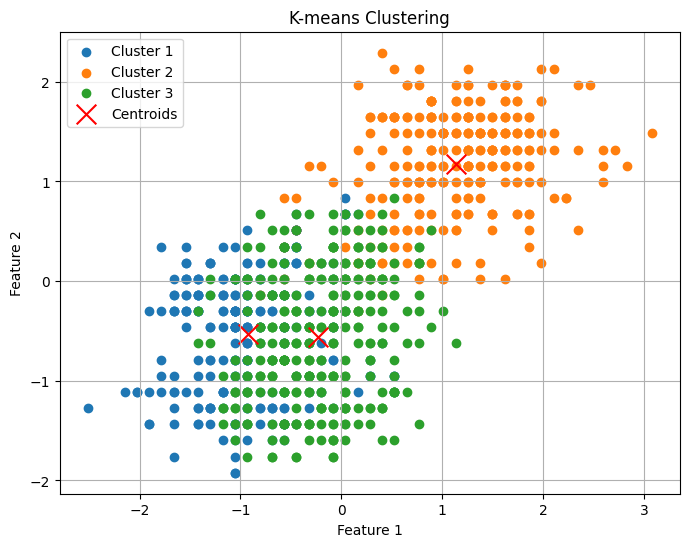

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Function to compute the Euclidean distance between two points
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b)**2))

# K-means clustering algorithm
def k_means(X, k, max_iters=100):
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]
    
    for _ in range(max_iters):
        # Assign labels to each point based on closest centroid
        labels = np.array([np.argmin([euclidean_distance(x, centroid) for centroid in centroids]) for x in X])
        
        # Update centroids
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        
        # If centroids do not change, stop the iteration
        if np.all(centroids == new_centroids):
            break
        
        centroids = new_centroids
    
    return centroids, labels

# Function to compute the Calinski-Harabasz Index
def calinski_harabasz_index(X, labels, centroids):
    n = X.shape[0]
    k = len(np.unique(labels))
    
    # Between-cluster dispersion
    B = np.sum([np.sum((centroid - np.mean(X, axis=0))**2) * (labels == i).sum() for i, centroid in enumerate(centroids)])
    
    # Within-cluster dispersion
    W = np.sum([np.sum(np.sum((X[labels == i] - centroid)**2, axis=1)) for i, centroid in enumerate(centroids)])
    
    # Calinski-Harabasz Index (Variance Ratio Criterion)
    return (B / (k - 1)) / (W / (n - k))

# Function to compute the Davies-Bouldin Index
def davies_bouldin_index(X, labels, centroids):
    k = len(np.unique(labels))
    
    # Compute the Davies-Bouldin Index
    S = np.array([np.mean(np.linalg.norm(X[labels == i] - centroid, axis=1)) for i, centroid in enumerate(centroids)])
    R = np.array([[np.linalg.norm(centroids[i] - centroids[j]) for j in range(k)] for i in range(k)])
    
    DBI = 0
    for i in range(k):
        DBI += np.max([(S[i] + S[j]) / R[i, j] for j in range(k) if i != j])
    
    return DBI / k

# Function to compute the Silhouette Coefficient
def silhouette_score(X, labels, centroids):
    n = X.shape[0]
    
    # Compute the Silhouette Score for each point
    silhouette_scores = []
    
    for i in range(n):
        # Compute the average distance to points in the same cluster (a_i)
        same_cluster_points = X[labels == labels[i]]
        a_i = np.mean([euclidean_distance(X[i], p) for p in same_cluster_points if not np.array_equal(X[i], p)])
        
        # Compute the average distance to points in the nearest different cluster (b_i)
        nearest_cluster_distances = []
        for j in range(len(centroids)):
            if j != labels[i]:
                other_cluster_points = X[labels == j]
                b_i = np.mean([euclidean_distance(X[i], p) for p in other_cluster_points])
                nearest_cluster_distances.append(b_i)
        
        b_i = min(nearest_cluster_distances)
        
        # Compute the Silhouette Score for the point
        silhouette_scores.append((b_i - a_i) / max(a_i, b_i))
    
    # Return the average silhouette score for the dataset
    return np.mean(silhouette_scores)

# Load the dataset
df = pd.read_csv('lab_vehicle.csv')

# Check for missing values and handle them
print(df.isnull().sum())

# Drop rows with missing values (if needed)
df = df.dropna()

# Manual standardization (mean = 0, std = 1)
scaled_data = (df - df.mean()) / df.std()
scaled_data = scaled_data.values  # Convert to NumPy array

# Set k (number of clusters)
k = 3  # Adjust as needed

# Apply K-means clustering
centroids, labels = k_means(scaled_data, k)

# Evaluate Clustering using the metrics
ch_score = calinski_harabasz_index(scaled_data, labels, centroids)
dbi_score = davies_bouldin_index(scaled_data, labels, centroids)
sil_score = silhouette_score(scaled_data, labels, centroids)

# Print the results of clustering metrics
print(f"Calinski-Harabasz Index: {ch_score}")
print(f"Davies-Bouldin Index: {dbi_score}")
print(f"Silhouette Score: {sil_score}")

# Visualize the clustering result
plt.figure(figsize=(8, 6))
for i in range(k):
    plt.scatter(scaled_data[labels == i][:, 0], scaled_data[labels == i][:, 1], label=f'Cluster {i+1}')
    
plt.scatter(centroids[:, 0], centroids[:, 1], color='red', marker='x', s=200, label='Centroids')
plt.title('K-means Clustering')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()


### Q3) Repeat the same for a dataset of your choice.

Calinski-Harabasz Index: 22399.940747172135
Davies-Bouldin Index: 0.8428336899667781
Silhouette Score: 0.43493351635321653


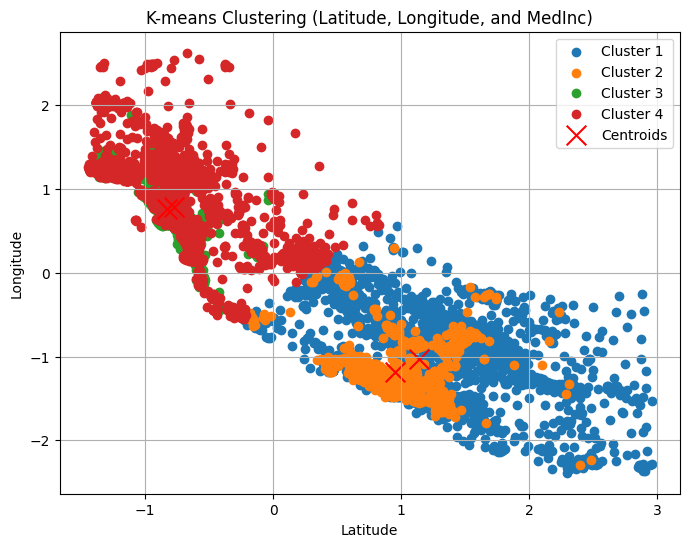

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score, silhouette_score

# Function to compute the Euclidean distance between two points
def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b)**2))

# K-means clustering algorithm
def k_means(X, k, max_iters=100):
    centroids = X[np.random.choice(X.shape[0], k, replace=False)]  # Initialize centroids randomly
    
    for _ in range(max_iters):
        # Assign labels based on closest centroid
        labels = np.array([np.argmin([euclidean_distance(x, centroid) for centroid in centroids]) for x in X])
        
        # Recalculate centroids as the mean of all points in the cluster
        new_centroids = np.array([X[labels == i].mean(axis=0) for i in range(k)])
        
        # Check for convergence (if centroids don't change)
        if np.all(centroids == new_centroids):
            break
        
        centroids = new_centroids
    
    return centroids, labels

# Load the California Housing dataset
df = pd.read_csv('housing.csv')

# We will use 'Latitude', 'Longitude', and 'MedInc' for clustering
features = ['latitude', 'longitude', 'median_income']
X = df[features].values

# Standardize the data (important for K-means)
scaler = StandardScaler()
scaled_data = scaler.fit_transform(X)

# Set the number of clusters
k = 4  # You can adjust the number of clusters as needed

# Apply K-means clustering using custom K-means function
centroids, labels = k_means(scaled_data, k)

# Evaluate Clustering using sklearn's evaluation metrics
ch_score = calinski_harabasz_score(scaled_data, labels)
dbi_score = davies_bouldin_score(scaled_data, labels)
sil_score = silhouette_score(scaled_data, labels)

# Print the results of clustering metrics
print(f"Calinski-Harabasz Index: {ch_score}")
print(f"Davies-Bouldin Index: {dbi_score}")
print(f"Silhouette Score: {sil_score}")

# Visualize the clustering result (using Latitude and Longitude for x and y axes)
def plot_k_means(X, centroids, labels, k):
    plt.figure(figsize=(8, 6))
    
    # Plot each cluster
    for i in range(k):
        plt.scatter(X[labels == i][:, 0], X[labels == i][:, 1], label=f'Cluster {i+1}')
        
    # Plot the centroids
    plt.scatter(centroids[:, 0], centroids[:, 1], color='red', marker='x', s=200, label='Centroids')
    
    plt.title('K-means Clustering (Latitude, Longitude, and MedInc)')
    plt.xlabel('Latitude')
    plt.ylabel('Longitude')
    plt.legend()
    plt.grid(True)
    plt.show()

# Visualize the clustering result
plot_k_means(scaled_data, centroids, labels, k)
